# Baseline Comparisons
Here, we compare the implementation of our Logistic Regression with two baselines. We train a **decision tree** with Gini impurity (an interpretable, rule-like partition of the feature space), **scikit-learn’s logistic regression**, and the **custom** `LogisticRegressionModel` from `src`. All three use the same standardized features and label encoding.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.logistic_regression import LogisticRegressionModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

In [2]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


In [3]:
# Preprocess data
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Baseline Comparisons - Utilizing all Features

Here, we train a **decision tree** with Gini impurity (an interpretable, rule-like partition of the feature space), **scikit-learn’s logistic regression**, and the **custom** `LogisticRegressionModel` from `src`. All three use the same standardized features and label encoding.

In [7]:
def metrics_row(name, y_true, y_pred):
    return {
        "model": name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "test_macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "test_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


comparison_rows = []
# Decision Tree
# Criterion: Gini impurity which can be used to measure the quality of a split in a decision tree
# max_depth: None which means that the tree can grow as large as possible
dt_clf = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
dt_clf.fit(X_train_s, y_train_enc)
pred_dt = dt_clf.predict(X_test_s)
comparison_rows.append(metrics_row("DecisionTree (Gini)", y_test_enc, pred_dt))

# Logistic Regression
# Use the best parameters found by optuna during hyperparameter tuning
learning_rate = 0.068
max_iter = 2500
# SKLearn Logistic Regression
# solver: "sag" is a solver that uses stochastic average gradient descent and SAG's varian reduction
#  uses the average of all stored gradients to update weights to reduce graien variance/noise
#  this solver is the closest solver to our implementation of Logistic Regression
lr_sklearn = SklearnLogisticRegression(solver="sag" ,max_iter=max_iter, random_state=RANDOM_STATE)
lr_sklearn.fit(X_train_s, y_train_enc)
pred_lr_sk = lr_sklearn.predict(X_test_s)
comparison_rows.append(metrics_row("sklearn LogisticRegression", y_test_enc, pred_lr_sk))
# Our implementation of Logistic Regression using full-batch gradient descent
model = LogisticRegressionModel(random_state=RANDOM_STATE, max_iter=max_iter)
model.fit(X_train_s, y_train_enc, learning_rate=learning_rate)
pred = model.predict(X_test_s)
comparison_rows.append(metrics_row("Custom LogisticRegressionModel", y_test_enc, pred))

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

/Users/romina/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,DecisionTree (Gini),0.862572,0.862767,0.859023,0.859807
1,sklearn LogisticRegression,0.950797,0.954340,0.949763,0.950958
2,Custom LogisticRegressionModel,0.943332,0.946819,0.942326,0.943596


DecisionTree (Gini)
                    precision    recall  f1-score   support

           WALKING      0.831     0.919     0.873       496
  WALKING_UPSTAIRS      0.827     0.783     0.805       471
WALKING_DOWNSTAIRS      0.888     0.829     0.857       420
           SITTING      0.833     0.764     0.797       491
          STANDING      0.798     0.859     0.827       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.863      2947
         macro avg      0.863     0.859     0.860      2947
      weighted avg      0.864     0.863     0.862      2947

sklearn LogisticRegression
                    precision    recall  f1-score   support

           WALKING      0.943     0.994     0.968       496
  WALKING_UPSTAIRS      0.957     0.947     0.952       471
WALKING_DOWNSTAIRS      0.990     0.943     0.966       420
           SITTING      0.964     0.864     0.911       491
          STANDING      0.875     0.970     0.920

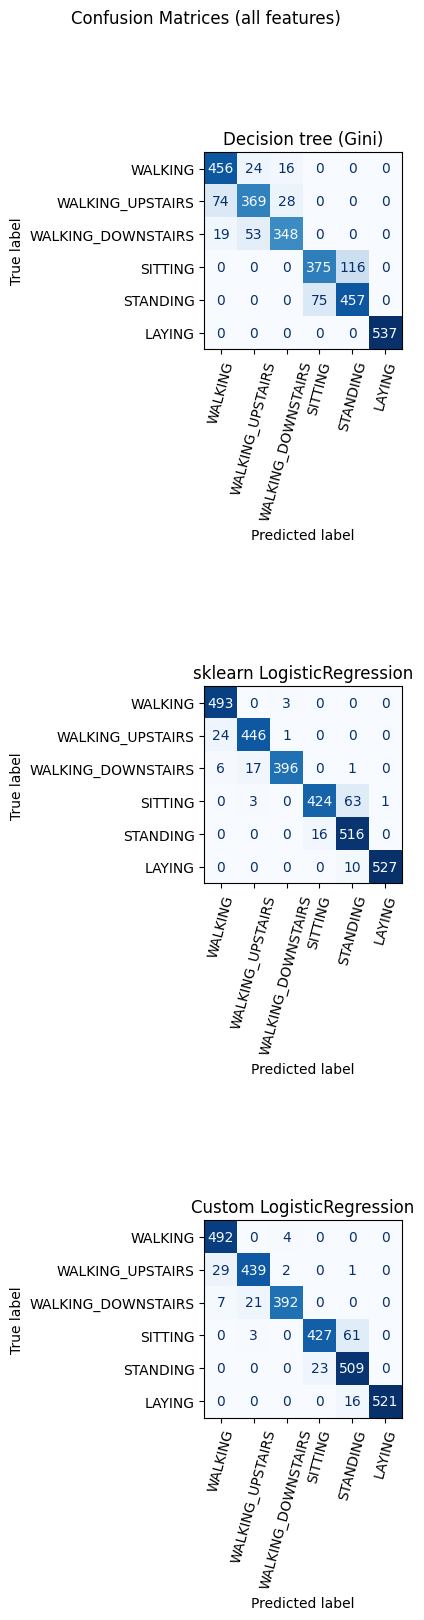

In [ ]:
label_order = activity_labels["activity_name"].to_list()

for name, y_hat in [
    ("DecisionTree (Gini)", pred_dt),
    ("sklearn LogisticRegression", pred_lr_sk),
    ("Custom LogisticRegressionModel", pred),
]:
    print("=" * 72)
    print(name)
    print("=" * 72)
    print(classification_report(y_test_enc, y_hat, target_names=target_names, digits=3))

fig, axes = plt.subplots(3, 1, figsize=(4, 16), constrained_layout=True)
for ax, (title, y_hat) in zip(
    axes,
    [
        ("Decision Tree (Gini)", pred_dt),
        ("sklearn LogisticRegression", pred_lr_sk),
        ("Custom LogisticRegression", pred),
    ],
):
    cm = confusion_matrix(y_test_enc, y_hat)
    disp = metrics.ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=label_order
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=75)
plt.suptitle("Confusion Matrices (all features)", y=1.02)
plt.show()

## Baseline Comparisons — PCA-Reduced Features

We use `fit_best_pca_then_transform` from `src.models.pca_reduction` to choose **n_components** (grid search with a probe logistic regression on a stratified train/validation split, stopping early when enough variance is explained). PCA is then fit on the **full** training set and applied to train and test. The same three models as above are trained on the reduced feature matrices.


In [10]:
from src.models.pca_reduction import fit_best_pca_then_transform

X_train_p, X_test_p, pca_model, pca_meta = fit_best_pca_then_transform(
    X_train_s,
    y_train_enc,
    X_test_s,
    random_state=RANDOM_STATE,
)
print(
    "PCA: n_components=%d | probe val accuracy=%.4f | train shape=%s | test shape=%s"
    % (
        pca_meta["n_components"],
        pca_meta["val_accuracy_probe"],
        X_train_p.shape,
        X_test_p.shape,
    )
)
print("PCA: variance explained (full train)=%.4f" % float(np.sum(pca_model.explained_variance_ratio_)))




2026-04-05-16:24 - pca - INFO - PCA search n_components=2 val_accuracy=0.5037 variance_explained=0.5739
2026-04-05-16:24 - pca - INFO - PCA search n_components=7 val_accuracy=0.8477 variance_explained=0.6769
2026-04-05-16:24 - pca - INFO - PCA search n_components=12 val_accuracy=0.8878 variance_explained=0.7253
2026-04-05-16:24 - pca - INFO - PCA search n_components=17 val_accuracy=0.9062 variance_explained=0.7576
2026-04-05-16:24 - pca - INFO - PCA search n_components=22 val_accuracy=0.9116 variance_explained=0.7843
2026-04-05-16:24 - pca - INFO - PCA search n_components=27 val_accuracy=0.9232 variance_explained=0.8066
2026-04-05-16:24 - pca - INFO - PCA search n_components=32 val_accuracy=0.9307 variance_explained=0.8258
2026-04-05-16:24 - pca - INFO - PCA search n_components=37 val_accuracy=0.9422 variance_explained=0.8424
2026-04-05-16:24 - pca - INFO - PCA search n_components=42 val_accuracy=0.9422 variance_explained=0.8565
2026-04-05-16:24 - pca - INFO - PCA search n_components=4

PCA: n_components=67 | probe val accuracy=0.9572 | train shape=(7352, 67) | test shape=(2947, 67)
PCA: variance explained (full train)=0.9073


In [11]:
comparison_rows_pca = []
dt_clf_p = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
dt_clf_p.fit(X_train_p, y_train_enc)
pred_dt_p = dt_clf_p.predict(X_test_p)
comparison_rows_pca.append(metrics_row("DecisionTree (Gini)", y_test_enc, pred_dt_p))

lr_sklearn_p = SklearnLogisticRegression(solver="sag", max_iter=max_iter, random_state=RANDOM_STATE)
lr_sklearn_p.fit(X_train_p, y_train_enc)
pred_lr_sk_p = lr_sklearn_p.predict(X_test_p)
comparison_rows_pca.append(metrics_row("sklearn LogisticRegression", y_test_enc, pred_lr_sk_p))

model_p = LogisticRegressionModel(random_state=RANDOM_STATE, max_iter=max_iter)
model_p.fit(X_train_p, y_train_enc, learning_rate=learning_rate)
pred_p = model_p.predict(X_test_p)
comparison_rows_pca.append(metrics_row("Custom LogisticRegressionModel", y_test_enc, pred_p))

comparison_df_pca = pd.DataFrame(comparison_rows_pca)
display(comparison_df_pca)

,model,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,DecisionTree (Gini),0.755684,0.756102,0.751139,0.752533
1,sklearn LogisticRegression,0.924669,0.925247,0.923099,0.923808
2,Custom LogisticRegressionModel,0.922633,0.923419,0.920580,0.921508


DecisionTree (Gini) (PCA-reduced features)
                    precision    recall  f1-score   support

           WALKING      0.746     0.825     0.784       496
  WALKING_UPSTAIRS      0.774     0.720     0.746       471
WALKING_DOWNSTAIRS      0.676     0.650     0.663       420
           SITTING      0.641     0.699     0.669       491
          STANDING      0.732     0.735     0.734       532
            LAYING      0.967     0.879     0.921       537

          accuracy                          0.756      2947
         macro avg      0.756     0.751     0.753      2947
      weighted avg      0.761     0.756     0.757      2947

sklearn LogisticRegression (PCA-reduced features)
                    precision    recall  f1-score   support

           WALKING      0.913     0.974     0.942       496
  WALKING_UPSTAIRS      0.913     0.894     0.903       471
WALKING_DOWNSTAIRS      0.955     0.907     0.930       420
           SITTING      0.892     0.862     0.877       491
   

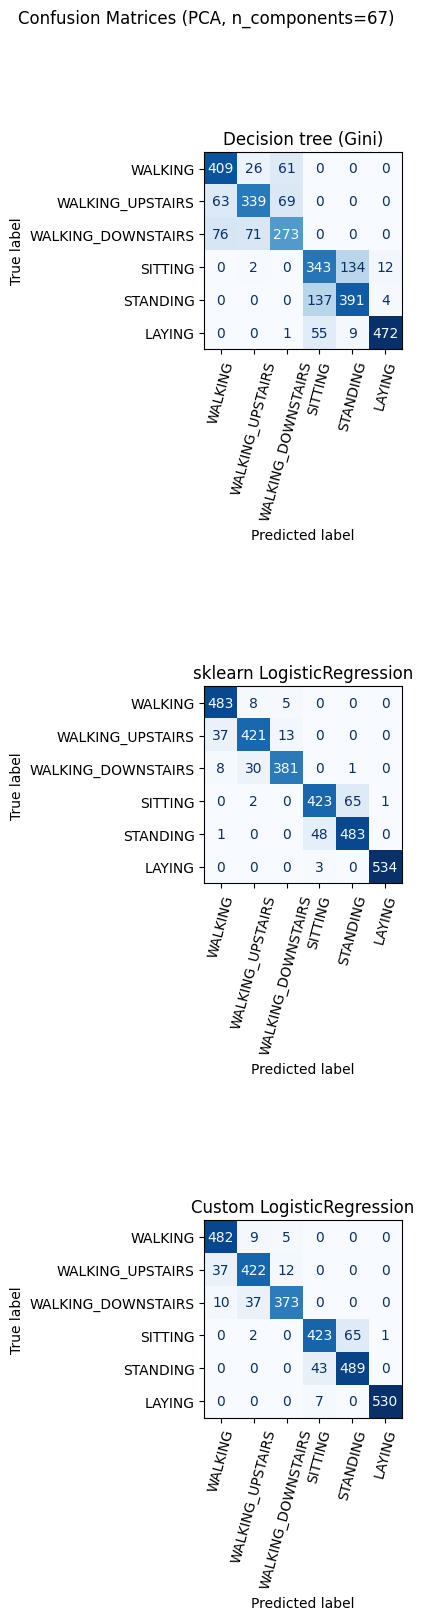

In [12]:
label_order = activity_labels["activity_name"].to_list()

for name, y_hat in [
    ("DecisionTree (Gini)", pred_dt_p),
    ("sklearn LogisticRegression", pred_lr_sk_p),
    ("Custom LogisticRegressionModel", pred_p),
]:
    print("=" * 72)
    print(name, "(PCA-reduced features)")
    print("=" * 72)
    print(classification_report(y_test_enc, y_hat, target_names=target_names, digits=3))

fig, axes = plt.subplots(3, 1, figsize=(4, 16), constrained_layout=True)
for ax, (title, y_hat) in zip(
    axes,
    [
        ("Decision tree (Gini)", pred_dt_p),
        ("sklearn LogisticRegression", pred_lr_sk_p),
        ("Custom LogisticRegression", pred_p),
    ],
):
    cm = confusion_matrix(y_test_enc, y_hat)
    disp = metrics.ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=label_order
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=75)
plt.suptitle(
    "Confusion Matrices (PCA, n_components=%d)" % pca_meta["n_components"],
    y=1.02,
)
plt.show()
